In [1]:
import numpy as np
import torch
import scanpy as sc
import anndata as ad
import pandas as pd
from utils.preprocess import *
import os
import sys
    
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper
from simulate.simulate import *
from omegaconf import OmegaConf
from utils.hydra import *
from datasets.process import *
from scripts.run_model import *
from eval.eval import *
import matplotlib.pyplot as plt
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
############################################################

In [3]:
config = load_config(overrides=['dataset=zebrafish_cns'])
OmegaConf.set_struct(config, False)
config.classifier.num_layers = 2
config.classifier.hidden_dim = 128
config.classifier.epsilon = 0.05

In [4]:
### SETTINGS ###

adata = process_data(pc_dim=config.pc_dim, 
                     t0_index=config.t0_index,
                     t1_index=config.t1_index,
                     data=config.data, 
                     use_paga=config.use_paga,
                     paga_threshold=config.paga_threshold,
                     tissue=config.tissue)

print(adata.obs['cell_type'].nunique())

timepoints = sorted(adata.obs['timepoint'].unique().tolist())
tree = adata.uns['tree']

config.num_classes = adata.obs['cell_type'].nunique()

print(config.t0_index)
print(config.t1_index)

/home/azweig/projects/finfm/datasets/process.py:61: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['cell_type'] = adata.obs['cell_type_broad']


17
1
4


/home/azweig/projects/finfm/utils/lineage.py:174: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns['stoi'] = stoi


In [5]:
adata.shape

(65554, 2000)

In [6]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]

adata = adata[(adata.obs['timepoint'] >= t0) & (adata.obs['timepoint'] <= t1)]
adata_train = adata[adata.obs['timepoint'].isin([t0, t1])]

print(t0, t1)

24 72


In [7]:
# #CFM
# config.metric = "cfm"
# config.use_euclidean_ot = True
# config.force_train_classifier = True
# config.metric_max_epochs = 2

In [8]:
#CFM + Finsler
config.metric = "cfm"

config.finsler.use = True
config.finsler.lamb = 0.5
config.balance_classes = False
config.metric_max_epochs = 2

In [9]:
# #MFM-Euc
# config.metric = "mfm"
# config.mfm.use_euclidean_ot = True

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

In [10]:
# #MFM
# config.metric = "mfm"

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

In [11]:
# #MFM + Finsler
# config.metric = "mfm"

# config.mfm.K = 150
# config.mfm.kappa = 1.5
# config.mfm.epsilon = 1e-1

# config.finsler.use = True
# config.finsler.lamb = 0.5

In [12]:
# from utils.lineage import *
# adj = ZEBRAFISH_NEURAL_ADJACENCY
# tree_cell_types = list(adj.keys()) + list(itertools.chain(*adj.values()))
# tree_cell_types = list(set(tree_cell_types))
# print(tree_cell_types)
# print(len(tree_cell_types))
# print(adata.uns['tree'])
# print([adata.uns['stoi'][x] for x in tree_cell_types])
# N = adata.uns['tree'].shape[0]
# for i in range(N):
#     for j in range(N):
#         if adata.uns['tree'][i][j] == 1.0:
#             print(adata.uns['itos'][i] + ", " + adata.uns['itos'][j])

In [13]:
# sc.pp.neighbors(adata)
# sc.tl.umap(adata)

In [14]:
# fig, axs = plt.subplots(5, figsize=(12, 12))
# for i, t in enumerate(timepoints):
#     sc.pl.umap(adata[adata.obs['timepoint'] == t], color='cell_type', ax=axs[i], title=f"time {t}", show=False)
# plt.tight_layout()
# plt.show()

In [15]:
# from scripts.run_gaga import *
# run_gaga_model(config, config.project, adata_train, timepoints, tree, wandb_logger=None)

In [16]:
singleton_dataloader = build_singleton_dataloader(config, adata_train)
paired_dataloader = build_paired_dataloader(config, adata_train)

In [17]:
classifier_model, metric_model, embed_model, flow_model = run_full_model(config=config,
                                                                         project=config.project,
                                                                         singleton_dataloader=singleton_dataloader,
                                                                         paired_dataloader=paired_dataloader,
                                                                         timepoints=timepoints,
                                                                         tree=tree)

{'pc_dim': 100, 'num_classes': 17, 'seeded': True, 'seed': 42, 'classifier_max_epochs': 1000, 'metric_max_epochs': 2, 'embed_max_epochs': 3000, 'flow_max_epochs': 2, 'gradient_clip_val': 0, 'warmup_steps': 0, 'loader_batch_size': 6, 'flow_batch_size': 512, 'score_batch_size': 2048, 'ema_decay': '1-1e-3', 'use_paga': False, 'paga_threshold': 0.0, 'lr': 0.001, 'dropout': 0.0, 'hidden_dim': 256, 'latent_dim': 100, 'num_layers': 3, 'num_freq': 32, 'rescale': 0.5, 'skip': False, 'normalize': True, 'balance_classes': False, 'force_cpu': False, 'detect_anomaly': False, 'use_wandb': True, 'dummy_prior': 0.05, 'dummy_kl_weight': 0.05, 'classifier': {'hidden_dim': 128, 'num_layers': 2, 'spectral_norm': False, 'epsilon': 0.05}, 'metric': 'cfm', 'sigma': 0.0, 'ot_in_embed': True, 'fast_ot': False, 'no_learning': False, 'time_per_batch': 4, 'random_velocities': False, 'force_icfm': False, 'method': 'exact', 'reg': -1, 'reg_m': -1, 'mfm': {'K': 150, 'kappa': 1.5, 'alpha': 1.0, 'epsilon': 0.1}, 'use_

wandb: Currently logged in as: az831 (az831-new-york-genome-center) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
You are using a CUDA device ('NVIDIA GeForce RTX 4080 SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name           | Type           | Params | Mode 
----------------------------------------------------

epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
train_ce,▇█▅▅▆▇▄▇▅▃▄▃▃▃▄▃▃▃▅▃▄▃▂▃▃▃▄▃▃▂▂▂▃▃▂▃▂▄▁▃
train_kl,▁████▇████▇█████████████████████████████
train_loss_classifier,█▆▅▅▄▅▄▃▄▃▃▃▃▃▃▃▃▂▃▂▂▄▃▂▂▃▃▃▂▃▃▁▁▂▄▃▂▁▂▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██
epoch,999
train_ce,1.14364
train_kl,1.96842
train_loss_classifier,1.24207
trainer/global_step,6999


Running phase metric:.......


...

epoch,▁▁▁▁▁▁▁███████
train_loss_metric,▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▂▂▃▃▄▄▅▅▆▆▇▇█
epoch,1
train_loss_metric,0
trainer/global_step,13


Running phase embed:.......


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type           | Params | Mode 
--------------------------------------------------------
0 | embed_net    | SimpleEmbedNet | 184 K  | train
1 | geo_net      | SinNet         | 226 K  | train
2 | metric_model | FinslerCFM     | 32.3 K | eval 
  | other params | n/a            | 50     | n/a  
--------------------------------------------------------
411 K     Trainable params
32.3 K    Non-trainable params
443 K     Total params
1.775     Total estimated

Restored best model from epoch 2925 with train_loss_geo_embed=0.247083


epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇██
train_loss_embed,█▆▅▅▅▄▅▄▄▄▃▄▃▃▃▃▃▄▃▃▃▃▂▂▂▃▂▂▁▂▂▁▁▂▂▂▁▂▁▁
train_loss_geo,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_geo_embed,█▃▃▃▂▃▂▂▂▂▂▂▁▂▂▂▂▁▁▂▁▁▁▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
epoch,2999
train_loss_embed,0.06988
train_loss_geo,0.20801
train_loss_geo_embed,0.27788
trainer/global_step,2999


In [18]:
remove_all_forward_hooks(classifier_model)
remove_all_forward_hooks(metric_model)
remove_all_forward_hooks(embed_model)
remove_all_forward_hooks(flow_model)

In [19]:
t0, t1 = timepoints[config.t0_index], timepoints[config.t1_index]

w1_scores = []
for index in range(config.t0_index + 1, config.t1_index):
    print(index)
    t = timepoints[index]
    w1 = predict(embed_model, adata, t0, t, t1, num_traj=6000, library="pot")
    w1_scores.append(w1)
w1_scores = torch.tensor(w1_scores)
print(w1_scores)
print(torch.mean(w1_scores))

2


/home/azweig/projects/finfm/models/embed_models.py:135: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(j)
/home/azweig/miniconda3/envs/spatialenv/lib/python3.10/site-packages/ot/lp/_network_simplex.py:574: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  check_result(result_code)


3
tensor([13.7832, 15.4254])
tensor(14.6043)


In [20]:
# paths = torch.load("cfm_paths.t")
# paths = torch.load("cfm_fin_paths.t")

In [21]:
itos = adata.uns['itos']
cell_types = [itos[i] for i in range(len(itos))] + ["outlier"]
color_map = {ct: plt.cm.tab20.colors[i] for i, ct in enumerate(cell_types)}
colors = [color_map[ct] for ct in cell_types]

/tmp/ipykernel_1440845/3287192690.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  logits = classifier_model.classify(torch.tensor(paths_flat, device=device).float())


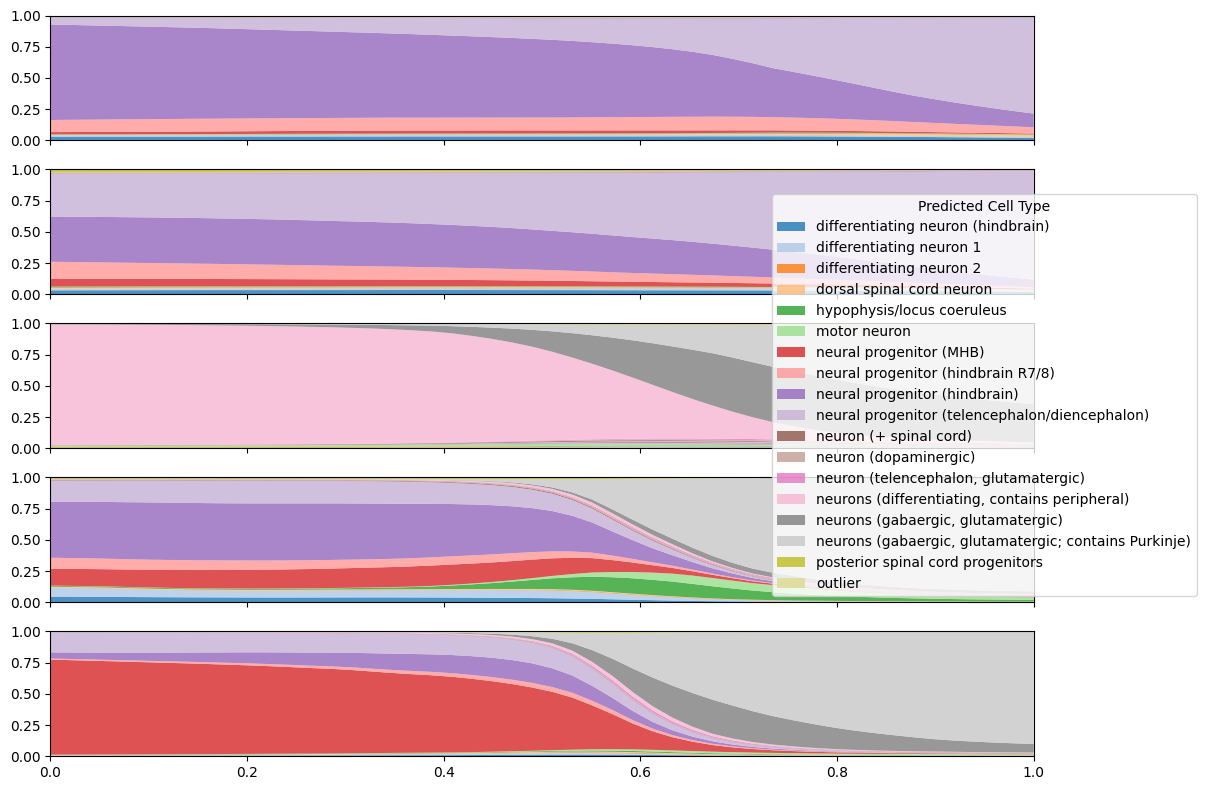

In [22]:
device = embed_model.device

batch = next(iter(paired_dataloader))
x0, x1, _, _ = embed_model._prepare_batch(batch)

paths = embed_model.sample_geodesic_path(batch, num_points=50)
paths_flat = paths.reshape(-1, paths.shape[-1])

time_axis = np.linspace(0, 1, 50)

with torch.no_grad():
    logits = classifier_model.classify(torch.tensor(paths_flat, device=device).float())
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    
probs = probs.reshape(paths.shape[0], paths.shape[1], -1)

itos = adata.uns['itos']

fig, axes = plt.subplots(5, figsize=(12, 8), sharex=True, sharey=True)

flat_axes = axes.flatten()

for i in range(len(flat_axes)):
    traj = probs[:,i]
    ax = flat_axes[i]
    ax.stackplot(time_axis, traj.T, labels=cell_types, alpha=0.8, colors=colors)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

handles, labels = flat_axes[0].get_legend_handles_labels()

fig.legend(
    handles, 
    labels, 
    loc='center right',       # Position on the right edge
    bbox_to_anchor=(1, 0.5),  # Anchor point relative to figure
    title="Predicted Cell Type"
)

plt.tight_layout(rect=[0, 0, 0.88, 1]) 
plt.show()

In [23]:
start = paths[0,:30]
end = paths[-1,:30]
itos = adata.uns['itos']
start_classes = torch.argmax(classifier_model.classify(start), dim=1).detach().cpu().numpy()
start_classes = [itos[i] for i in start_classes]
end_classes = torch.argmax(classifier_model.classify(end), dim=1).detach().cpu().numpy()
end_classes = [itos[i] for i in end_classes]

for i in range(5):
    print(f"{start_classes[i]:<50} {end_classes[i]:>50}")


neural progenitor (hindbrain)                          neural progenitor (telencephalon/diencephalon)
neural progenitor (hindbrain)                          neural progenitor (telencephalon/diencephalon)
neurons (differentiating, contains peripheral)     neurons (gabaergic, glutamatergic; contains Purkinje)
neural progenitor (hindbrain)                      neurons (gabaergic, glutamatergic; contains Purkinje)
neural progenitor (MHB)                            neurons (gabaergic, glutamatergic; contains Purkinje)


In [24]:
#24->36,48->72
#Central Nervous System
#Pure ctrl-inj
#PCA over all

#CFM: 14.6907
#CFM + Finsler: 14.4766

#MFM-Euc: 13.8179
#MFM: 13.9356
#MFM + Finsler: 13.7898

In [25]:
#24->36,48->72
#Pharyngeal Arch
#Pure ctrl-inj
#PCA over all

#CFM: 
#CFM + Finsler:

#MFM-Euc: 
#MFM: 
#MFM + Finsler:

In [26]:
#24->36,48->72
#Pharyngeal Arch

#CFM: 14.0418
#CFM + Finsler: 13.8820

#MFM-Euc: 
#MFM: 13.1617
#MFM + Finsler: 13.1270

In [27]:
#24->36,48->72
#Pharyngeal Arch
#Using paper's tree
#PCA derived on t0 and t1

#CFM: 13.8556
#CFM + Finsler: 13.8556

#MFM-Euc: 
#MFM: 12.8655
#MFM + Finsler: 12.8978

In [28]:
#18->24,36,48->72
#Pharyngeal Arch

#CFM: 13.8812
#CFM + Finsler: 13.6659

#MFM-Euc: 
#MFM: 13.1065
#MFM + Finsler: 13.0844

In [29]:
paths.shape

torch.Size([50, 512, 100])

In [30]:
# if config.pc_dim <= 5:

#         # t0 = 0
#         # t1 = 1

#         # samples = torch.from_numpy(adata.obsm['X_pca']).float()
#         # fig, axs = plt.subplots(1, figsize = (15, 8))
#         # scatter0 = axs.scatter(samples[:,0], samples[:, 1], c=adata.obs['cell_type'].astype(int).tolist())
#         # handles, labels = scatter0.legend_elements()
#         # axs.legend(handles, labels, title="Timepoints")
#         # for i in range(5):
#         #         axs.plot(paths[:, i, 0], paths[:,i, 1], marker=".", linestyle="-", alpha=1, lw=1.5, color='orange')
#         # axs.set_aspect('equal')

#         # plt.show()

#         import matplotlib.pyplot as plt
#         import seaborn as sns

#         samples = torch.from_numpy(adata.obsm['X_pca']).float()
#         fig, axs = plt.subplots(1, figsize=(15, 8))

#         sns.scatterplot(
#         x=samples[:, 0].numpy(), 
#         y=samples[:, 1].numpy(), 
#         hue=adata.obs['cell_type'], # Colors by this column
#         ax=axs,
#         s=30,
#         edgecolor=None
#         )

#         axs.legend(title="Cell Type", bbox_to_anchor=(1, 1), loc='upper left')

#         for i in range(5):
#                 axs.plot(paths[:, i, 0], paths[:, i, 1], marker=".", linestyle="-", alpha=1, lw=1.5, color='orange')

#         axs.set_aspect('equal')
#         plt.show()

In [31]:
# import umap
# import numpy as np
# import matplotlib.pyplot as plt

# X_data = adata.obsm['X_pca']

# umap_model = umap.UMAP(n_neighbors=15, min_dist=0.5, metric='euclidean') 
# X_umap = umap_model.fit_transform(X_data)
# adata.obsm['X_umap'] = X_umap

# traj_umap = umap_model.transform(paths.reshape(-1, 100))
# traj_umap = traj_umap.reshape((-1, 512, 2))

In [32]:

# import seaborn as sns

# fig, ax = plt.subplots(figsize=(8, 8))

# sns.scatterplot(
#     x=X_umap[:, 0],
#     y=X_umap[:, 1],
#     hue=adata.obs['cell_type'], # Directly pass the categorical column
#     s=10,
#     ax=ax,
#     palette='tab10', # Or use a specific palette
#     edgecolor=None   # Removes outlines for a cleaner look
# )
# for i in range(3):
#     plt.plot(traj_umap[:, i, 0], traj_umap[:,i, 1], c='red', linewidth=3, label='Learned Trajectory')

# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
# plt.show()

# plt.figure(figsize=(8,8))



In [33]:
# # PHATE Visualization: Ground Truth, Predictions, Entropy, Trajectories

# import phate
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.neighbors import NearestNeighbors
# from mpl_toolkits.axes_grid1 import make_axes_locatable

# def project_to_phate(new_points, X_original, X_phate_embedding, k=10):
#     """Project points to PHATE space via KNN interpolation."""
#     knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
#     knn.fit(X_original)
#     distances, indices = knn.kneighbors(new_points)
#     weights = 1.0 / (distances + 1e-10)
#     weights = weights / weights.sum(axis=1, keepdims=True)
#     projected = np.zeros((len(new_points), 2))
#     for i in range(len(new_points)):
#         projected[i] = np.average(X_phate_embedding[indices[i]], axis=0, weights=weights[i])
#     return projected

# # Fit PHATE on PCA data
# X_data = adata.obsm['X_pca']
# phate_op = phate.PHATE(n_components=2, knn=15, t='auto', random_state=42, verbose=True)
# X_phate = phate_op.fit_transform(X_data)
# adata.obsm['X_phate'] = X_phate

# # Project trajectories to PHATE space
# paths_flat_np = paths.reshape(-1, paths.shape[-1])
# if isinstance(paths_flat_np, torch.Tensor):
#     paths_flat_np = paths_flat_np.detach().cpu().numpy()
# traj_phate = project_to_phate(paths_flat_np, X_data, X_phate, k=10)
# traj_phate = traj_phate.reshape(paths.shape[0], paths.shape[1], 2)

# # Compute classifier predictions and entropy
# device = classifier_model.device
# with torch.no_grad():
#     X_tensor = torch.tensor(X_data, device=device, dtype=torch.float32)
#     logits = classifier_model.classify(X_tensor)
#     probs = torch.softmax(logits, dim=1).cpu().numpy()

# ground_truth = adata.obs['cell_type'].values
# predicted_classes = np.argmax(probs, axis=1)
# itos = adata.uns['itos']
# predicted_labels = np.array([itos[i] if i < len(itos) else 'outlier' for i in predicted_classes])

# epsilon = 1e-10
# entropy = -np.sum(probs * np.log(probs + epsilon), axis=1)
# entropy_normalized = entropy / np.log(probs.shape[1])

# # Create 2x2 figure
# fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# unique_cell_types = adata.obs['cell_type'].unique()
# palette = sns.color_palette('tab20', len(unique_cell_types))
# color_map = {ct: palette[i] for i, ct in enumerate(unique_cell_types)}

# # Panel 1: Ground Truth Labels
# ax1 = axs[0, 0]
# for ct in unique_cell_types:
#     mask = adata.obs['cell_type'] == ct
#     ax1.scatter(X_phate[mask, 0], X_phate[mask, 1], c=[color_map[ct]], label=ct, s=5, alpha=0.6)
# ax1.set_title('Ground Truth Cell Types')
# ax1.set_xlabel('PHATE 1')
# ax1.set_ylabel('PHATE 2')

# # Panel 2: Classifier Predicted Labels
# ax2 = axs[0, 1]
# for ct in unique_cell_types:
#     mask = predicted_labels == ct
#     if mask.sum() > 0:
#         ax2.scatter(X_phate[mask, 0], X_phate[mask, 1], c=[color_map[ct]], label=ct, s=5, alpha=0.6)
# outlier_mask = predicted_labels == 'outlier'
# if outlier_mask.sum() > 0:
#     ax2.scatter(X_phate[outlier_mask, 0], X_phate[outlier_mask, 1], c='gray', label='outlier', s=5, alpha=0.6)
# ax2.set_title('Classifier Predicted Cell Types')
# ax2.set_xlabel('PHATE 1')
# ax2.set_ylabel('PHATE 2')

# # Panel 3: Classifier Entropy
# ax3 = axs[1, 0]
# scatter3 = ax3.scatter(X_phate[:, 0], X_phate[:, 1], c=entropy_normalized, cmap='plasma', s=5, alpha=0.7, vmin=0, vmax=1)
# ax3.set_title('Classifier Entropy (Uncertainty)')
# ax3.set_xlabel('PHATE 1')
# ax3.set_ylabel('PHATE 2')
# divider3 = make_axes_locatable(ax3)
# cax3 = divider3.append_axes("right", size="5%", pad=0.05)
# plt.colorbar(scatter3, cax=cax3, label='Normalized Entropy')

# # Panel 4: Trajectories
# ax4 = axs[1, 1]
# ax4.scatter(X_phate[:, 0], X_phate[:, 1], c='lightgray', s=3, alpha=0.3)
# num_traj = 5
# traj_indices = np.linspace(0, paths.shape[1]-1, num_traj, dtype=int)
# colors = plt.cm.viridis(np.linspace(0, 1, num_traj))
# for idx, ti in enumerate(traj_indices):
#     traj = traj_phate[:, ti, :]
#     ax4.plot(traj[:, 0], traj[:, 1], c=colors[idx], linewidth=2, alpha=0.8)
#     ax4.scatter(traj[0, 0], traj[0, 1], c='green', s=50, marker='o', edgecolor='black', zorder=5)
#     ax4.scatter(traj[-1, 0], traj[-1, 1], c='red', s=50, marker='s', edgecolor='black', zorder=5)
# ax4.set_title('Learned Geodesic Trajectories')
# ax4.set_xlabel('PHATE 1')
# ax4.set_ylabel('PHATE 2')

# handles, labels = ax1.get_legend_handles_labels()
# fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.15, 0.5), title='Cell Types', fontsize=8)
# plt.tight_layout(rect=[0, 0, 0.88, 1])
# plt.suptitle('PHATE Visualization of Zebrafish Neural Development', fontsize=14, y=1.02)
# plt.show()